In [ ]:
from math import pi
def sub_of_radian(input1, input2):
    # 计算两个弧度的差值，范围为[-pi, pi]
    diff = input1 - input2
    diff = (diff + pi) % (2 * pi) - pi
    return diff

def sub_of_degree(input1, input2):
    # 计算两个角度的差值，范围为[-180, 180]
    diff = input1 - input2
    diff = (diff + 180) % (360) - 180
    return diff

靠近

0 in 200 epidosdes
1 in 200 epidosdes
2 in 200 epidosdes
3 in 200 epidosdes


C:\Users\LYH\AppData\Local\Temp\ipykernel_18816\3434775652.py:111: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\builder\windows\pytorch\torch\csrc\utils\tensor_new.cpp:281.)
  state = torch.tensor([state], dtype=torch.float).to(self.device)


4 in 200 epidosdes
5 in 200 epidosdes
6 in 200 epidosdes
7 in 200 epidosdes
8 in 200 epidosdes
9 in 200 epidosdes
10 in 200 epidosdes
11 in 200 epidosdes
12 in 200 epidosdes
13 in 200 epidosdes
14 in 200 epidosdes
15 in 200 epidosdes
16 in 200 epidosdes
17 in 200 epidosdes
18 in 200 epidosdes
19 in 200 epidosdes
20 in 200 epidosdes
21 in 200 epidosdes
22 in 200 epidosdes
23 in 200 epidosdes
24 in 200 epidosdes
25 in 200 epidosdes
26 in 200 epidosdes
27 in 200 epidosdes
28 in 200 epidosdes
29 in 200 epidosdes
30 in 200 epidosdes
31 in 200 epidosdes
32 in 200 epidosdes
33 in 200 epidosdes
34 in 200 epidosdes
35 in 200 epidosdes
36 in 200 epidosdes
37 in 200 epidosdes
38 in 200 epidosdes
39 in 200 epidosdes
40 in 200 epidosdes
41 in 200 epidosdes
42 in 200 epidosdes
43 in 200 epidosdes
44 in 200 epidosdes
45 in 200 epidosdes
46 in 200 epidosdes
47 in 200 epidosdes
48 in 200 epidosdes
49 in 200 epidosdes
50 in 200 epidosdes
51 in 200 epidosdes
52 in 200 epidosdes
53 in 200 epidosdes
54 in 

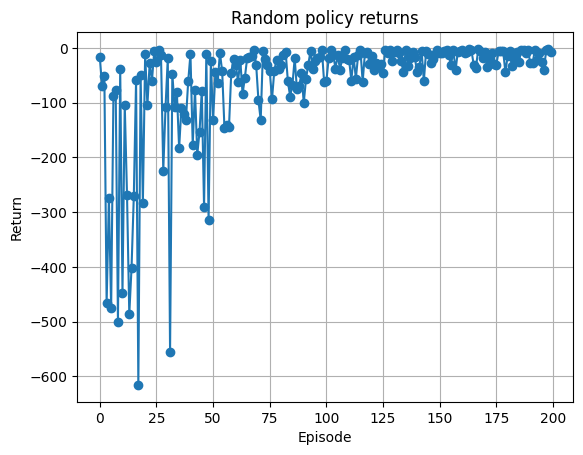

状态： [-2.96546293  0.18539242]
状态： [-2.76546293  2.        ]
状态： [-2.56546293  2.        ]
状态： [-2.36546293  2.        ]
状态： [-2.16546293  2.        ]
状态： [-1.96546293  2.        ]
状态： [-1.76546293  2.        ]
状态： [-1.56546293  2.        ]
状态： [-1.36546293  2.        ]
状态： [-1.16546293  2.        ]
状态： [-0.97597017  1.89492762]
状态： [-0.81144317  1.64526999]
状态： [-0.67161664  1.39826524]
状态： [-0.55233266  1.19283986]
状态： [-0.45151797  1.00814688]
状态： [-0.36636051  0.85157454]
状态： [-0.29504779  0.7131272 ]
状态： [-0.23571875  0.59329045]
状态： [-0.18799423  0.47724524]
状态： [-0.14952212  0.38472101]
状态： [-0.11852198  0.31000143]
状态： [-0.09346878  0.25053206]
状态： [-0.07289657  0.20572209]
状态： [-0.05561445  0.17282112]
状态： [-0.04108506  0.14529395]
状态： [-0.02882819  0.12256865]
状态： [-0.01854719  0.10281006]
状态： [-0.00993314  0.08614044]
状态： [-0.0026891   0.07244042]
状态： [0.00344091 0.0613001 ]
状态： [0.00864403 0.0520312 ]
状态： [0.01306735 0.04423318]
状态： [0.01684858 0.03781236]
状态： [0.02007924 0.

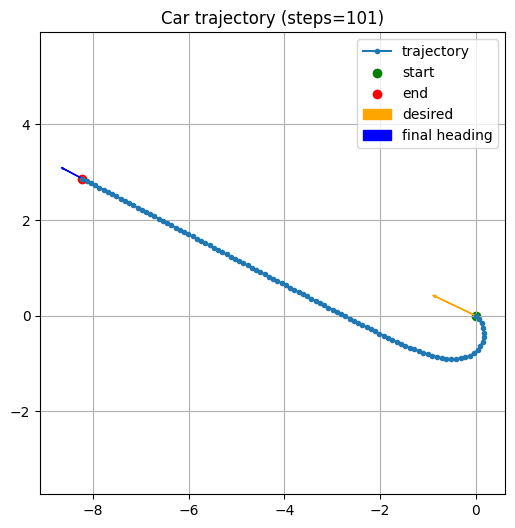

In [ ]:
import math
import numpy as np
import gymnasium as gym
from gymnasium import spaces
import matplotlib.pyplot as plt

def _wrap_angle(a):
    return (a + math.pi) % (2 * math.pi) - math.pi

import random
import gym
import numpy as np
from tqdm import tqdm
import collections
import torch
from torch import nn
import torch.nn.functional as F

from gym import spaces
from numpy.linalg import norm
from torch.distributions import Normal

# 超参数
actor_lr = 1e-3 / 10  # 1e-4 1e-6  # 2e-5 警告，学习率过大会出现"nan"
critic_lr = actor_lr * 10  # 1e-3  9e-3  5e-3 为什么critic学习率大于一都不会梯度爆炸？ 为什么设置成1e-5 也会爆炸？ chatgpt说要actor的2~10倍
num_episodes = 200  # 2000
hidden_dim = [128]  # 128
gamma = 0.9
lmbda = 0.9
epochs = 10  # 10
eps = 0.2


def moving_average(a, window_size):
    cumulative_sum = np.cumsum(np.insert(a, 0, 0))
    middle = (cumulative_sum[window_size:] - cumulative_sum[:-window_size]) / window_size
    r = np.arange(1, window_size - 1, 2)
    begin = np.cumsum(a[:window_size - 1])[::2] / r
    end = (np.cumsum(a[:-window_size:-1])[::2] / r)[::-1]
    return np.concatenate((begin, middle, end))


def compute_advantage(gamma, lmbda, td_delta):
    td_delta = td_delta.detach().numpy()
    advantage_list = []
    advantage = 0.0
    for delta in td_delta[::-1]:
        advantage = gamma * lmbda * advantage + delta
        advantage_list.append(advantage)
    advantage_list.reverse()
    return torch.tensor(advantage_list, dtype=torch.float)


class ValueNet(torch.nn.Module):
    def __init__(self, state_dim, hidden_dim):
        super(ValueNet, self).__init__()
        # self.prelu = torch.nn.PReLU()

        layers = []
        prev_size = state_dim
        for layer_size in hidden_dim:
            layers.append(torch.nn.Linear(prev_size, layer_size))
            layers.append(nn.ReLU())
            prev_size = layer_size
        self.net = nn.Sequential(*layers)
        self.fc_out = torch.nn.Linear(prev_size, 1)  # todo 补充多维输出

    def forward(self, x):
        y = self.net(x)
        return self.fc_out(y)


class PolicyNetContinuous(torch.nn.Module):
    def __init__(self, state_dim, hidden_dim, action_dim):
        super(PolicyNetContinuous, self).__init__()
        layers = []
        prev_size = state_dim
        for layer_size in hidden_dim:
            layers.append(nn.Linear(prev_size, layer_size))
            layers.append(nn.ReLU())
            prev_size = layer_size
        self.net = nn.Sequential(*layers)
        self.fc_mu = torch.nn.Linear(prev_size, action_dim)
        self.fc_std = torch.nn.Linear(prev_size, action_dim)

    def forward(self, x, action_bound=1.0, min_std=1e-3):
        x = self.net(x)
        mu = action_bound * self.fc_mu(x)
        std = action_bound * F.softplus(self.fc_std(x))  # + 1e-8
        std = torch.clamp(std, min=min_std)  # 设置 std 的最小值
        return mu, std


class PPOContinuous:
    ''' 处理连续动作的PPO算法 '''

    def __init__(self, state_dim, hidden_dim, action_dim, actor_lr, critic_lr,
                 lmbda, epochs, eps, gamma, device):
        self.actor = PolicyNetContinuous(state_dim, hidden_dim, action_dim).to(device)
        self.critic = ValueNet(state_dim, hidden_dim).to(device)
        self.actor_optimizer = torch.optim.Adam(self.actor.parameters(), lr=actor_lr)
        self.critic_optimizer = torch.optim.Adam(self.critic.parameters(), lr=critic_lr)

        self.gamma = gamma
        self.lmbda = lmbda
        self.epochs = epochs
        self.eps = eps
        self.device = device

    def take_action(self, state, action_bound=2.0, explore=True):
        state = torch.tensor([state], dtype=torch.float).to(self.device)
        mu, sigma = self.actor(state, action_bound=action_bound)
        if not explore:
            action = mu
            return action[0].cpu().detach().numpy().flatten()  # 支持一维和多维动作，而不是.item只支持1维或.squeeze只支持多维
        action_dist = torch.distributions.Normal(mu, sigma)
        action = action_dist.sample()
        return action[0].cpu().detach().numpy().flatten()  # 支持一维和多维动作，而不是.item只支持1维或.squeeze只支持多维
        # return [action.item()]

    def update(self, transition_dict, action_bound=1):
        states = torch.tensor(transition_dict['states'],
                              dtype=torch.float).to(self.device)
        # actions = torch.tensor(transition_dict['actions'],
        #                        dtype=torch.float).view(-1, 1).to(self.device)
        # fixme actions不适合flatten
        actions = torch.tensor(transition_dict['actions'],
                               dtype=torch.float).to(self.device)
        rewards = torch.tensor(transition_dict['rewards'],
                               dtype=torch.float).view(-1, 1).to(self.device)
        next_states = torch.tensor(transition_dict['next_states'],
                                   dtype=torch.float).to(self.device)
        dones = torch.tensor(transition_dict['dones'],
                             dtype=torch.float).view(-1, 1).to(self.device)

        mu, std = self.actor(states, action_bound=action_bound)  # 均值、方差
        # 添加Actor NaN检查
        if torch.isnan(mu).any() or torch.isnan(std).any():
            raise ValueError("NaN in Actor outputs before loop")
        # 添加Critic NaN检查
        critic_values = self.critic(states)
        if torch.isnan(critic_values).any():
            raise ValueError("NaN in Critic outputs before loop")

        td_target = rewards + self.gamma * self.critic(next_states) * (1 - dones)  # 时序差分回报值
        td_delta = td_target - self.critic(states)  # 优势函数用时序差分回报与Critic网络输出作差表示
        advantage = compute_advantage(self.gamma, self.lmbda, td_delta.cpu()).to(self.device)

        action_dists = torch.distributions.Normal(mu.detach(), std.detach())
        # 动作是正态分布
        old_log_probs = action_dists.log_prob(actions)

        if torch.isnan(old_log_probs).any():
            raise ValueError("替代动作无法被转换")

        for _ in range(self.epochs):
            mu, std = self.actor(states, action_bound=action_bound)
            # 添加Actor NaN检查
            if torch.isnan(mu).any() or torch.isnan(std).any():
                raise ValueError("NaN in Actor outputs in loop")
            critic_values = self.critic(states)
            # 添加Critic NaN检查
            if torch.isnan(critic_values).any():
                raise ValueError("NaN in Critic outputs in loop")

            action_dists = torch.distributions.Normal(mu, std)
            log_probs = action_dists.log_prob(actions)

            ratio = torch.exp(log_probs - old_log_probs)

            # print(ratio)
            # test 给actor更新添加熵正则项
            dist_entropy = action_dists.entropy()  # 获取熵

            surr1 = ratio * advantage
            surr2 = torch.clamp(ratio, 1 - self.eps, 1 + self.eps) * advantage  # 截断
            # actor_loss = torch.mean(-torch.min(surr1, surr2)) # original
            actor_loss = torch.sum(torch.min(surr1, surr2), dim=-1, keepdim=True)  # test
            # print(actor_loss)
            # 计算 dist_entropy 的均值

            entropy_term = 0.1 * dist_entropy.mean()  # 添加熵正则项
            actor_loss = -actor_loss.mean() - entropy_term  # 合并熵项 # test Actor更新加一个熵项

            critic_loss = torch.mean(
                F.mse_loss(self.critic(states), td_target.detach()))
            self.actor_optimizer.zero_grad()
            self.critic_optimizer.zero_grad()
            actor_loss.backward()
            critic_loss.backward()

            # 梯度裁剪
            nn.utils.clip_grad_norm_(self.actor.parameters(), max_norm=2)
            nn.utils.clip_grad_norm_(self.critic.parameters(), max_norm=2)

            self.actor_optimizer.step()
            self.critic_optimizer.step()


class CarHeadingEnv(gym.Env):
    """
    Simple planar car with constant forward speed.
    - State: [heading_error, heading_error_rate]
      heading_error = wrap(desired_heading - current_heading) in radians
      heading_error_rate approximated by finite difference
    - Action: angular velocity (rad/s), continuous scalar
    - Each episode runs fixed n_steps (default 100)
    - Reward: dense, negative quadratic of heading_error: r = - (heading_error**2)
    - render(): plots trajectory using matplotlib (collects positions during episode)
    Gymnasium API: reset() -> (obs, info), step(a) -> (obs, reward, terminated, truncated, info)
    """
    metadata = {"render_modes": ["human"]}

    def __init__(self,
                 max_steps: int = 100,
                 dt: float = 0.1,
                 speed: float = 1.0,
                 max_omega: float = 2.0,
                 seed: int = None):
        super().__init__()
        self.max_steps = int(max_steps)
        self.dt = float(dt)
        self.speed = float(speed)
        self.max_omega = float(max_omega)

        # action: angular velocity scalar
        self.action_space = spaces.Box(low=np.array([-self.max_omega], dtype=np.float32),
                                       high=np.array([self.max_omega], dtype=np.float32),
                                       shape=(1,), dtype=np.float32)
        # observation: heading_error in radians (-pi,pi), derivative (rad/s) bounded
        obs_high = np.array([math.pi, self.max_omega * 2], dtype=np.float32)
        obs_low = -obs_high
        self.observation_space = spaces.Box(low=obs_low, high=obs_high, dtype=np.float32)

        self._rng = np.random.RandomState(seed) if seed is not None else np.random.RandomState()
        self.seed(seed)

        # internal state
        self.current_heading = 0.0
        self.desired_heading = 0.0
        self.prev_error = 0.0
        self.step_count = 0
        self.error_dot = 0.0

        # rendering buffers
        self.x = 0.0
        self.y = 0.0
        self.trajectory = []

    def seed(self, seed=None):
        self._rng = np.random.RandomState(seed)

    def get_state(self,):
        error = _wrap_angle(self.desired_heading - self.current_heading)
        error_dot = self.error_dot
        return np.array([error, error_dot])

    def reset(self, *, seed=None, options=None):
        if seed is not None:
            self.seed(seed)
        # randomize headings (uniform -pi..pi)
        self.current_heading = self._rng.uniform(-math.pi, math.pi)
        self.desired_heading = self._rng.uniform(-math.pi, math.pi)
        self.prev_error = _wrap_angle(self.desired_heading - self.current_heading)
        self.step_count = 0

        # reset pose for render
        self.x, self.y = 0.0, 0.0
        self.trajectory = [(self.x, self.y)]

        obs = np.array([self.prev_error, 0.0], dtype=np.float32)  # error, error_dot (0 at reset)
        return obs, {}

    def step(self, action):
        # clip action
        omega = float(np.clip(action, -self.max_omega, self.max_omega).item() if hasattr(action, "item") else np.clip(action, -self.max_omega, self.max_omega))
        # apply continuous-time approximate dynamics
        # heading integrates angular velocity
        self.current_heading = _wrap_angle(self.current_heading + omega * self.dt)

        # update position (for render) with constant forward speed along current heading
        self.x += self.speed * math.cos(self.current_heading) * self.dt
        self.y += self.speed * math.sin(self.current_heading) * self.dt
        self.trajectory.append((self.x, self.y))

        # compute new error and derivative
        error = _wrap_angle(self.desired_heading - self.current_heading)
        self.error_dot = _wrap_angle(error-self.prev_error) / self.dt

        # reward: dense, negative quadratic of heading error (you can scale)
        reward = - (error ** 2)

        self.prev_error = error
        self.step_count += 1
        terminated = bool(self.step_count >= self.max_steps)
        truncated = False

        obs = np.array([error, self.error_dot], dtype=np.float32)
        info = {"current_heading": float(self.current_heading),
                "desired_heading": float(self.desired_heading),
                "step": int(self.step_count)}
        return obs, float(reward), terminated, truncated, info

    def render(self, mode="human", show=True):
        # visualize trajectory and headings
        xs, ys = zip(*self.trajectory) if self.trajectory else ([0.0], [0.0])
        plt.figure(figsize=(6,6))
        plt.plot(xs, ys, '-o', markersize=3, label='trajectory')
        plt.scatter([xs[0]], [ys[0]], c='green', label='start')
        plt.scatter([xs[-1]], [ys[-1]], c='red', label='end')

        # draw desired heading vector from origin
        origin = (0.0, 0.0)
        dhx = math.cos(self.desired_heading)
        dhy = math.sin(self.desired_heading)
        plt.arrow(origin[0], origin[1], dhx, dhy, head_width=0.05, color='orange', length_includes_head=True, label='desired')

        # draw final heading vector from last position
        fhx = math.cos(self.current_heading)
        fhy = math.sin(self.current_heading)
        plt.arrow(xs[-1], ys[-1], fhx * 0.5, fhy * 0.5, head_width=0.03, color='blue', length_includes_head=True, label='final heading')

        plt.axis('equal')
        plt.grid(True)
        plt.title(f"Car trajectory (steps={len(xs)})")
        plt.legend()
        if show:
            plt.show()

    def close(self):
        plt.close('all')


import numpy as np
import matplotlib.pyplot as plt

# 假设 CarHeadingEnv 已在当前命名空间定义为 CarHeadingEnv（如 notebook 前面单元格）
env = CarHeadingEnv(max_steps=100, dt=0.1, speed=1.0, max_omega=2.0, seed=0)
env.seed(0)
np.random.seed(0)

device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
state_dim = 2
action_dim = 1
action_bound = 1  # 动作最大值
agent = PPOContinuous(state_dim, hidden_dim, action_dim, actor_lr, critic_lr,
                      lmbda, epochs, eps, gamma, device)

returns = []

for ep in range(num_episodes):
    print(ep, "in", num_episodes, "epidosdes")
    obs, info = env.reset()
    ep_ret = 0.0
    transition_dict = {'states': [], 'actions': [], 'next_states': [], 'rewards': [], 'dones': []}
    done = False
    for t in range(env.max_steps):
        # 随机策略：从动作空间采样
        action = agent.take_action(obs, action_bound=action_bound, explore=True)
        step_res = env.step(action)
        # 兼容不同 gym / gymnasium 返回签名
        if len(step_res) == 5:
            next_obs, reward, terminated, truncated, info = step_res
            done = bool(terminated or truncated)
        else:
            next_obs, reward, done, info = step_res
        transition_dict['states'].append(obs)
        transition_dict['actions'].append(action)
        transition_dict['next_states'].append(next_obs)
        transition_dict['rewards'].append(reward)
        transition_dict['dones'].append(done)
        ep_ret += float(reward)
        obs = next_obs
        if done:
            break
    returns.append(ep_ret)
    agent.update(transition_dict)

print(f"episodes: {num_episodes}, mean return: {np.mean(returns):.3f}, std: {np.std(returns):.3f}")

# 绘制每回合总回报
plt.figure()
plt.plot(returns, '-o')
plt.xlabel('Episode')
plt.ylabel('Return')
plt.title('Random policy returns')
plt.grid(True)
plt.show()

# 可视化一个示例回合轨迹（重新运行一次并调用 render）
obs, info = env.reset()
for t in range(env.max_steps):
    print("状态：", env.get_state())
    # action = env.action_space.sample()
    action = agent.take_action(obs, action_bound=action_bound, explore=False)
    step_res = env.step(action)
    if len(step_res) == 5:
        next_obs, reward, terminated, truncated, info = step_res
        done = bool(terminated or truncated)
    else:
        next_obs, reward, done, info = step_res
    obs= next_obs
    if done:
        break

env.render()   # matplotlib 显示轨迹

远离

0 in 200 epidosdes
10 in 200 epidosdes
20 in 200 epidosdes
30 in 200 epidosdes
40 in 200 epidosdes
50 in 200 epidosdes
60 in 200 epidosdes
70 in 200 epidosdes
80 in 200 epidosdes
90 in 200 epidosdes
100 in 200 epidosdes
110 in 200 epidosdes
120 in 200 epidosdes
130 in 200 epidosdes
140 in 200 epidosdes
150 in 200 epidosdes
160 in 200 epidosdes
170 in 200 epidosdes
180 in 200 epidosdes
190 in 200 epidosdes
episodes: 200, mean return: 623.972, std: 317.918


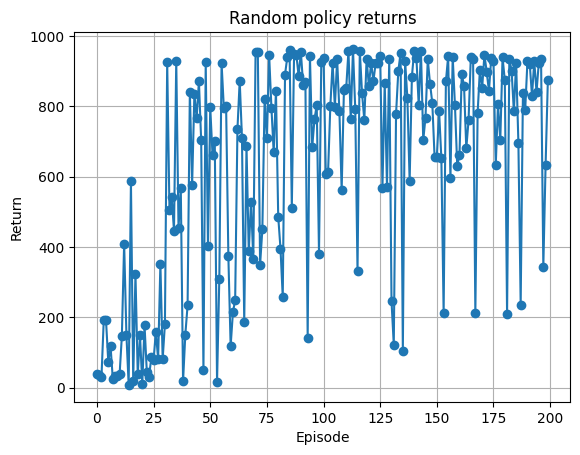

状态： [-2.96546293 -0.5666123 ]
状态： [-3.04329413 -0.77831203]
状态： [-3.13399497 -0.90700835]
状态： [ 3.05426832 -0.94922024]
状态： [-3.13632973  0.92587262]
状态： [ 3.08015504 -0.66700536]
状态： [-3.09861059  1.04419672]
状态： [ 3.12045454 -0.64120173]
状态： [-3.05607068  1.0666008 ]
状态： [-3.11879112 -0.62720436]
状态： [ 3.07414917 -0.9024502 ]
状态： [-3.11415572  0.9488042 ]
状态： [ 3.10303662 -0.65992969]
状态： [-3.07476304  1.05385649]
状态： [-3.13814461 -0.63381571]
状态： [ 3.05422963 -0.90811062]
状态： [-3.13488032  0.94075352]
状态： [ 3.08179221 -0.66512775]
状态： [-3.0968489   1.04544199]
状态： [ 3.12227922 -0.64057189]
状态： [-3.05416634  1.06739748]
状态： [-3.11682739 -0.62661052]
状态： [ 3.07616919 -0.9018873 ]
状态： [-3.11205446  0.94961661]
状态： [ 3.10519651 -0.65934336]
状态： [-3.07251527  1.0547353 ]
状态： [-3.13582773 -0.63312465]
状态： [ 3.05661279 -0.90744787]
状态： [-3.13240138  0.94171143]
状态： [ 3.08433255 -0.66451383]
状态： [-3.09420826  1.04644501]
状态： [ 3.1250006  -0.63976449]
状态： [-3.05133144  1.06853271]
状态： [-3.11

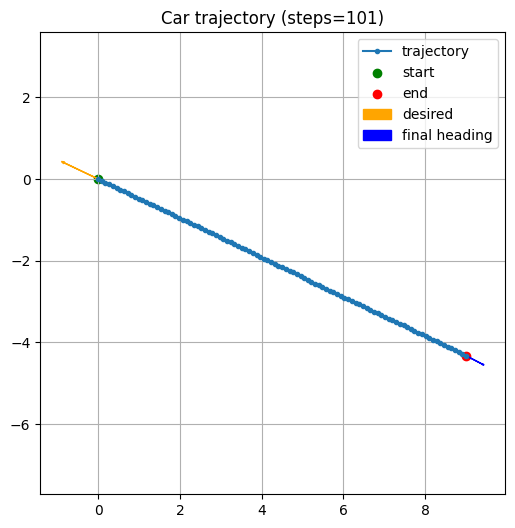

In [15]:
# 超参数
actor_lr = 1e-3 / 10  # 1e-4 1e-6  # 2e-5 警告，学习率过大会出现"nan"
critic_lr = actor_lr * 10  # 1e-3  9e-3  5e-3 为什么critic学习率大于一都不会梯度爆炸？ 为什么设置成1e-5 也会爆炸？ chatgpt说要actor的2~10倍
num_episodes = 200  # 2000
hidden_dim = [128]  # 128
gamma = 0.9
lmbda = 0.9
epochs = 10  # 10
eps = 0.2

class CarHeadingEnv(gym.Env):
    """
    Simple planar car with constant forward speed.
    - State: [heading_error, heading_error_rate]
      heading_error = wrap(desired_heading - current_heading) in radians
      heading_error_rate approximated by finite difference
    - Action: angular velocity (rad/s), continuous scalar
    - Each episode runs fixed n_steps (default 100)
    - Reward: dense, negative quadratic of heading_error: r = - (heading_error**2)
    - render(): plots trajectory using matplotlib (collects positions during episode)
    Gymnasium API: reset() -> (obs, info), step(a) -> (obs, reward, terminated, truncated, info)
    """
    metadata = {"render_modes": ["human"]}

    def __init__(self,
                 max_steps: int = 100,
                 dt: float = 0.1,
                 speed: float = 1.0,
                 max_omega: float = 2.0,
                 seed: int = None):
        super().__init__()
        self.max_steps = int(max_steps)
        self.dt = float(dt)
        self.speed = float(speed)
        self.max_omega = float(max_omega)

        # action: angular velocity scalar
        self.action_space = spaces.Box(low=np.array([-self.max_omega], dtype=np.float32),
                                       high=np.array([self.max_omega], dtype=np.float32),
                                       shape=(1,), dtype=np.float32)
        # observation: heading_error in radians (-pi,pi), derivative (rad/s) bounded
        obs_high = np.array([math.pi, self.max_omega * 2], dtype=np.float32)
        obs_low = -obs_high
        self.observation_space = spaces.Box(low=obs_low, high=obs_high, dtype=np.float32)

        self._rng = np.random.RandomState(seed) if seed is not None else np.random.RandomState()
        self.seed(seed)

        # internal state
        self.current_heading = 0.0
        self.desired_heading = 0.0
        self.prev_error = 0.0
        self.step_count = 0
        self.error_dot = 0.0

        # rendering buffers
        self.x = 0.0
        self.y = 0.0
        self.trajectory = []

    def seed(self, seed=None):
        self._rng = np.random.RandomState(seed)

    def get_state(self,):
        error = _wrap_angle(self.desired_heading - self.current_heading)
        error_dot = self.error_dot
        return np.array([error, error_dot])

    def reset(self, *, seed=None, options=None):
        if seed is not None:
            self.seed(seed)
        # randomize headings (uniform -pi..pi)
        self.current_heading = self._rng.uniform(-math.pi, math.pi)
        self.desired_heading = self._rng.uniform(-math.pi, math.pi)
        self.prev_error = _wrap_angle(self.desired_heading - self.current_heading)
        self.step_count = 0

        # reset pose for render
        self.x, self.y = 0.0, 0.0
        self.trajectory = [(self.x, self.y)]

        obs = np.array([self.prev_error, 0.0], dtype=np.float32)  # error, error_dot (0 at reset)
        return obs, {}

    def step(self, action):
        # clip action
        omega = float(np.clip(action, -self.max_omega, self.max_omega).item() if hasattr(action, "item") else np.clip(action, -self.max_omega, self.max_omega))
        # apply continuous-time approximate dynamics
        # heading integrates angular velocity
        self.current_heading = _wrap_angle(self.current_heading + omega * self.dt)

        # update position (for render) with constant forward speed along current heading
        self.x += self.speed * math.cos(self.current_heading) * self.dt
        self.y += self.speed * math.sin(self.current_heading) * self.dt
        self.trajectory.append((self.x, self.y))

        # compute new error and derivative
        error = _wrap_angle(self.desired_heading - self.current_heading)
        self.error_dot = _wrap_angle(error-self.prev_error) / self.dt

        # reward: dense, negative quadratic of heading error (you can scale)
        reward = + (error ** 2)

        self.prev_error = error
        self.step_count += 1
        terminated = bool(self.step_count >= self.max_steps)
        truncated = False

        obs = np.array([error, self.error_dot], dtype=np.float32)
        info = {"current_heading": float(self.current_heading),
                "desired_heading": float(self.desired_heading),
                "step": int(self.step_count)}
        return obs, float(reward), terminated, truncated, info

    def render(self, mode="human", show=True):
        # visualize trajectory and headings
        xs, ys = zip(*self.trajectory) if self.trajectory else ([0.0], [0.0])
        plt.figure(figsize=(6,6))
        plt.plot(xs, ys, '-o', markersize=3, label='trajectory')
        plt.scatter([xs[0]], [ys[0]], c='green', label='start')
        plt.scatter([xs[-1]], [ys[-1]], c='red', label='end')

        # draw desired heading vector from origin
        origin = (0.0, 0.0)
        dhx = math.cos(self.desired_heading)
        dhy = math.sin(self.desired_heading)
        plt.arrow(origin[0], origin[1], dhx, dhy, head_width=0.05, color='orange', length_includes_head=True, label='desired')

        # draw final heading vector from last position
        fhx = math.cos(self.current_heading)
        fhy = math.sin(self.current_heading)
        plt.arrow(xs[-1], ys[-1], fhx * 0.5, fhy * 0.5, head_width=0.03, color='blue', length_includes_head=True, label='final heading')

        plt.axis('equal')
        plt.grid(True)
        plt.title(f"Car trajectory (steps={len(xs)})")
        plt.legend()
        if show:
            plt.show()

    def close(self):
        plt.close('all')


import numpy as np
import matplotlib.pyplot as plt

# 假设 CarHeadingEnv 已在当前命名空间定义为 CarHeadingEnv（如 notebook 前面单元格）
env = CarHeadingEnv(max_steps=100, dt=0.1, speed=1.0, max_omega=2.0, seed=0)
env.seed(0)
np.random.seed(0)

device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
state_dim = 2
action_dim = 1
action_bound = 1  # 动作最大值
agent = PPOContinuous(state_dim, hidden_dim, action_dim, actor_lr, critic_lr,
                      lmbda, epochs, eps, gamma, device)

returns = []

for ep in range(num_episodes):
    if ep %10 ==0:
        print(ep, "in", num_episodes, "epidosdes")
    obs, info = env.reset()
    ep_ret = 0.0
    transition_dict = {'states': [], 'actions': [], 'next_states': [], 'rewards': [], 'dones': []}
    done = False
    for t in range(env.max_steps):
        # 随机策略：从动作空间采样
        action = agent.take_action(obs, action_bound=action_bound, explore=True)
        step_res = env.step(action)
        # 兼容不同 gym / gymnasium 返回签名
        if len(step_res) == 5:
            next_obs, reward, terminated, truncated, info = step_res
            done = bool(terminated or truncated)
        else:
            next_obs, reward, done, info = step_res
        transition_dict['states'].append(obs)
        transition_dict['actions'].append(action)
        transition_dict['next_states'].append(next_obs)
        transition_dict['rewards'].append(reward)
        transition_dict['dones'].append(done)
        ep_ret += float(reward)
        obs = next_obs
        if done:
            break
    returns.append(ep_ret)
    agent.update(transition_dict)

print(f"episodes: {num_episodes}, mean return: {np.mean(returns):.3f}, std: {np.std(returns):.3f}")

# 绘制每回合总回报
plt.figure()
plt.plot(returns, '-o')
plt.xlabel('Episode')
plt.ylabel('Return')
plt.title('Random policy returns')
plt.grid(True)
plt.show()

# 可视化一个示例回合轨迹（重新运行一次并调用 render）
obs, info = env.reset()
for t in range(env.max_steps):
    print("状态：", env.get_state())
    # action = env.action_space.sample()
    action = agent.take_action(obs, action_bound=action_bound, explore=False)
    step_res = env.step(action)
    if len(step_res) == 5:
        next_obs, reward, terminated, truncated, info = step_res
        done = bool(terminated or truncated)
    else:
        next_obs, reward, done, info = step_res
    obs= next_obs
    if done:
        break

env.render()   # matplotlib 显示轨迹

蛇形

0 in 200 epidosdes
10 in 200 epidosdes
20 in 200 epidosdes
30 in 200 epidosdes
40 in 200 epidosdes
50 in 200 epidosdes
60 in 200 epidosdes
70 in 200 epidosdes
80 in 200 epidosdes
90 in 200 epidosdes
100 in 200 epidosdes
110 in 200 epidosdes
120 in 200 epidosdes
130 in 200 epidosdes
140 in 200 epidosdes
150 in 200 epidosdes
160 in 200 epidosdes
170 in 200 epidosdes
180 in 200 epidosdes
190 in 200 epidosdes
episodes: 200, mean return: 69.429, std: 110.177


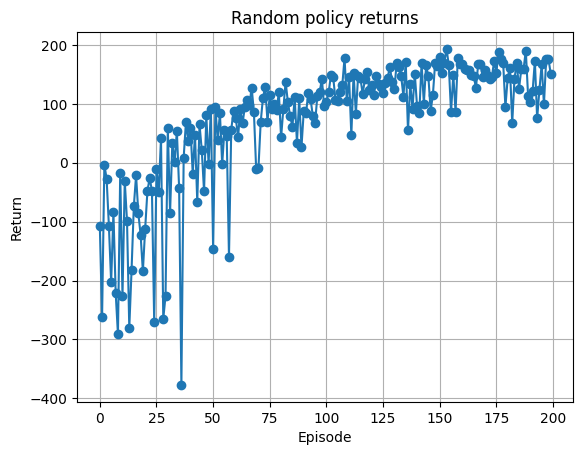

状态： [-2.96546293 -2.        ]
状态： [-2.76546293  2.        ]
状态： [-2.56546293  2.        ]
状态： [-2.36546293  2.        ]
状态： [-2.16546293  2.        ]
状态： [-1.96546293  2.        ]
状态： [-1.76546293  2.        ]
状态： [-1.56546293  2.        ]
状态： [-1.36546293  2.        ]
状态： [-1.16546293  2.        ]
状态： [-0.96546293  2.        ]
状态： [-0.76546293  2.        ]
状态： [-0.56546293  2.        ]
状态： [-0.36546293  2.        ]
状态： [-0.16546293  2.        ]
状态： [0.03453707 2.        ]
状态： [0.22650584 1.91968763]
状态： [0.35706465 1.30558813]
状态： [0.40816509 0.51100439]
状态： [ 0.38520135 -0.22963737]
状态： [ 0.32066621 -0.64535141]
状态： [ 0.2384195  -0.82246709]
状态： [ 0.16358273 -0.74836773]
状态： [ 0.11631648 -0.47266245]
状态： [ 0.11062644 -0.05690044]
状态： [0.13436768 0.23741247]
状态： [0.17141601 0.37048328]
状态： [0.21088684 0.39470828]
状态： [0.24151374 0.30626902]
状态： [0.25645169 0.14937952]
状态： [ 0.25569985 -0.00751849]
状态： [ 0.24420146 -0.11498387]
状态： [ 0.22844163 -0.15759833]
状态： [ 0.21428195 -0.14159672

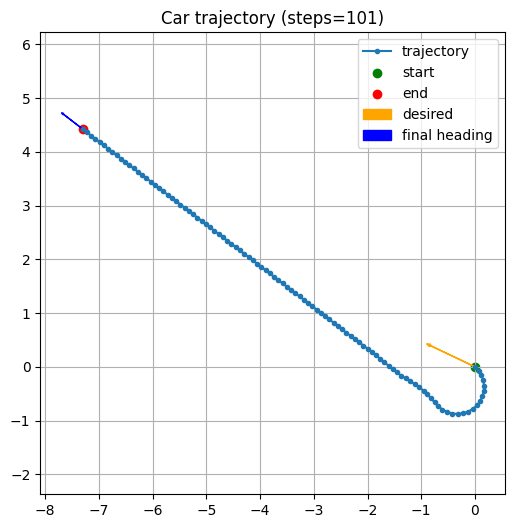

In [20]:
# 超参数
actor_lr = 1e-3 / 10  # 1e-4 1e-6  # 2e-5 警告，学习率过大会出现"nan"
critic_lr = actor_lr * 10  # 1e-3  9e-3  5e-3 为什么critic学习率大于一都不会梯度爆炸？ 为什么设置成1e-5 也会爆炸？ chatgpt说要actor的2~10倍
num_episodes = 200  # 2000
hidden_dim = [128]  # 128
gamma = 0.9
lmbda = 0.9
epochs = 10  # 10
eps = 0.2

class CarHeadingEnv(gym.Env):
    """
    Simple planar car with constant forward speed.
    - State: [heading_error, heading_error_rate]
      heading_error = wrap(desired_heading - current_heading) in radians
      heading_error_rate approximated by finite difference
    - Action: angular velocity (rad/s), continuous scalar
    - Each episode runs fixed n_steps (default 100)
    - Reward: dense, negative quadratic of heading_error: r = - (heading_error**2)
    - render(): plots trajectory using matplotlib (collects positions during episode)
    Gymnasium API: reset() -> (obs, info), step(a) -> (obs, reward, terminated, truncated, info)
    """
    metadata = {"render_modes": ["human"]}

    def __init__(self,
                 max_steps: int = 100,
                 dt: float = 0.1,
                 speed: float = 1.0,
                 max_omega: float = 2.0,
                 seed: int = None):
        super().__init__()
        self.max_steps = int(max_steps)
        self.dt = float(dt)
        self.speed = float(speed)
        self.max_omega = float(max_omega)

        # action: angular velocity scalar
        self.action_space = spaces.Box(low=np.array([-self.max_omega], dtype=np.float32),
                                       high=np.array([self.max_omega], dtype=np.float32),
                                       shape=(1,), dtype=np.float32)
        # observation: heading_error in radians (-pi,pi), derivative (rad/s) bounded
        obs_high = np.array([math.pi, self.max_omega * 2], dtype=np.float32)
        obs_low = -obs_high
        self.observation_space = spaces.Box(low=obs_low, high=obs_high, dtype=np.float32)

        self._rng = np.random.RandomState(seed) if seed is not None else np.random.RandomState()
        self.seed(seed)

        # internal state
        self.current_heading = 0.0
        self.desired_heading = 0.0
        self.prev_error = 0.0
        self.step_count = 0
        self.error_dot = 0.0

        # rendering buffers
        self.x = 0.0
        self.y = 0.0
        self.trajectory = []

    def seed(self, seed=None):
        self._rng = np.random.RandomState(seed)

    def get_state(self,):
        error = _wrap_angle(self.desired_heading - self.current_heading)
        error_dot = self.error_dot
        return np.array([error, error_dot])

    def reset(self, *, seed=None, options=None):
        if seed is not None:
            self.seed(seed)
        # randomize headings (uniform -pi..pi)
        self.current_heading = self._rng.uniform(-math.pi, math.pi)
        self.desired_heading = self._rng.uniform(-math.pi, math.pi)
        self.prev_error = _wrap_angle(self.desired_heading - self.current_heading)
        self.step_count = 0

        # reset pose for render
        self.x, self.y = 0.0, 0.0
        self.trajectory = [(self.x, self.y)]

        obs = np.array([self.prev_error, 0.0], dtype=np.float32)  # error, error_dot (0 at reset)
        return obs, {}

    def step(self, action):
        # clip action
        omega = float(np.clip(action, -self.max_omega, self.max_omega).item() if hasattr(action, "item") else np.clip(action, -self.max_omega, self.max_omega))
        # apply continuous-time approximate dynamics
        # heading integrates angular velocity
        self.current_heading = _wrap_angle(self.current_heading + omega * self.dt)

        # update position (for render) with constant forward speed along current heading
        self.x += self.speed * math.cos(self.current_heading) * self.dt
        self.y += self.speed * math.sin(self.current_heading) * self.dt
        self.trajectory.append((self.x, self.y))

        # compute new error and derivative
        error = _wrap_angle(self.desired_heading - self.current_heading)
        self.error_dot = _wrap_angle(error-self.prev_error) / self.dt

        # reward: dense, negative quadratic of heading error (you can scale)
        reward = -1 * (error ** 2) + 0.6 * self.error_dot ** 2

        self.prev_error = error
        self.step_count += 1
        terminated = bool(self.step_count >= self.max_steps)
        truncated = False

        obs = np.array([error, self.error_dot], dtype=np.float32)
        info = {"current_heading": float(self.current_heading),
                "desired_heading": float(self.desired_heading),
                "step": int(self.step_count)}
        return obs, float(reward), terminated, truncated, info

    def render(self, mode="human", show=True):
        # visualize trajectory and headings
        xs, ys = zip(*self.trajectory) if self.trajectory else ([0.0], [0.0])
        plt.figure(figsize=(6,6))
        plt.plot(xs, ys, '-o', markersize=3, label='trajectory')
        plt.scatter([xs[0]], [ys[0]], c='green', label='start')
        plt.scatter([xs[-1]], [ys[-1]], c='red', label='end')

        # draw desired heading vector from origin
        origin = (0.0, 0.0)
        dhx = math.cos(self.desired_heading)
        dhy = math.sin(self.desired_heading)
        plt.arrow(origin[0], origin[1], dhx, dhy, head_width=0.05, color='orange', length_includes_head=True, label='desired')

        # draw final heading vector from last position
        fhx = math.cos(self.current_heading)
        fhy = math.sin(self.current_heading)
        plt.arrow(xs[-1], ys[-1], fhx * 0.5, fhy * 0.5, head_width=0.03, color='blue', length_includes_head=True, label='final heading')

        plt.axis('equal')
        plt.grid(True)
        plt.title(f"Car trajectory (steps={len(xs)})")
        plt.legend()
        if show:
            plt.show()

    def close(self):
        plt.close('all')


import numpy as np
import matplotlib.pyplot as plt

# 假设 CarHeadingEnv 已在当前命名空间定义为 CarHeadingEnv（如 notebook 前面单元格）
env = CarHeadingEnv(max_steps=100, dt=0.1, speed=1.0, max_omega=2.0, seed=0)
env.seed(0)
np.random.seed(0)

device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
state_dim = 2
action_dim = 1
action_bound = 1  # 动作最大值
agent = PPOContinuous(state_dim, hidden_dim, action_dim, actor_lr, critic_lr,
                      lmbda, epochs, eps, gamma, device)

returns = []

for ep in range(num_episodes):
    if ep %10 ==0:
        print(ep, "in", num_episodes, "epidosdes")
    obs, info = env.reset()
    ep_ret = 0.0
    transition_dict = {'states': [], 'actions': [], 'next_states': [], 'rewards': [], 'dones': []}
    done = False
    for t in range(env.max_steps):
        # 随机策略：从动作空间采样
        action = agent.take_action(obs, action_bound=action_bound, explore=True)
        step_res = env.step(action)
        # 兼容不同 gym / gymnasium 返回签名
        if len(step_res) == 5:
            next_obs, reward, terminated, truncated, info = step_res
            done = bool(terminated or truncated)
        else:
            next_obs, reward, done, info = step_res
        transition_dict['states'].append(obs)
        transition_dict['actions'].append(action)
        transition_dict['next_states'].append(next_obs)
        transition_dict['rewards'].append(reward)
        transition_dict['dones'].append(done)
        ep_ret += float(reward)
        obs = next_obs
        if done:
            break
    returns.append(ep_ret)
    agent.update(transition_dict)

print(f"episodes: {num_episodes}, mean return: {np.mean(returns):.3f}, std: {np.std(returns):.3f}")

# 绘制每回合总回报
plt.figure()
plt.plot(returns, '-o')
plt.xlabel('Episode')
plt.ylabel('Return')
plt.title('Random policy returns')
plt.grid(True)
plt.show()

# 可视化一个示例回合轨迹（重新运行一次并调用 render）
obs, info = env.reset()
for t in range(env.max_steps):
    print("状态：", env.get_state())
    # action = env.action_space.sample()
    action = agent.take_action(obs, action_bound=action_bound, explore=False)
    step_res = env.step(action)
    if len(step_res) == 5:
        next_obs, reward, terminated, truncated, info = step_res
        done = bool(terminated or truncated)
    else:
        next_obs, reward, done, info = step_res
    obs= next_obs
    if done:
        break

env.render()   # matplotlib 显示轨迹